# Fine‑Tuning MobileNetV2 + SVM Pipeline
This notebook reproduces the full training, feature extraction, SVM training, and evaluation steps previously implemented in a Python script.

## Imports

In [25]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from skimage.feature import hog
from joblib import dump, load
from tqdm import tqdm


In [2]:
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"

import tensorflow as tf
from tensorflow import keras

## Configuration

In [26]:
TRAIN_DIR = "../data/train"
VAL_DIR   = "../data/val"
TEST_DIR  = "../data/test"

## Data Generators

In [27]:
def extract_hog_features(img_path):
    img = cv2.imread(img_path)
    
    # Check if image was loaded successfully
    if img is None:
        raise FileNotFoundError(f"Could not load image at: {img_path}")
    
    
    img = cv2.resize(img, (128, 128))
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    features = hog(
        gray,
        orientations=12,           # ← Try 12 instead of 9
        pixels_per_cell=(6, 6),    # ← Try smaller cells (6x6 instead of 8x8)
        cells_per_block=(3, 3),    # ← Try 3x3 instead of 2x2
        block_norm="L2-Hys",
        transform_sqrt=True        # ← Add this for better contrast normalization
    )

    return features

## Build MobileNetV2 Base Model

In [28]:
def load_dataset(directory):
    X = []
    y = []
    class_names = sorted(os.listdir(directory))

    for label, class_name in enumerate(class_names):
        class_dir = os.path.join(directory, class_name)

        if not os.path.isdir(class_dir):
            continue

        print(f"Loading {class_name} ...")

        for filename in tqdm(os.listdir(class_dir)):
            file_path = os.path.join(class_dir, filename)

            if filename.lower().endswith((".jpg", ".jpeg", ".png")):
                features = extract_hog_features(file_path)
                X.append(features)
                y.append(label)

    return np.array(X), np.array(y), class_names


## Train Head

In [30]:
X_train, y_train, class_names = load_dataset(TRAIN_DIR)
X_val, y_val, _              = load_dataset(VAL_DIR)
X_test, y_test, _            = load_dataset(TEST_DIR)

print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)
print("Classes:", class_names)


Loading NORMAL ...


100%|██████████| 185/185 [00:05<00:00, 31.95it/s]


Loading PNEUMONIA ...


100%|██████████| 347/347 [00:06<00:00, 54.91it/s]


Loading NORMAL ...


...

Loading NORMAL ...


100%|██████████| 234/234 [00:05<00:00, 41.25it/s]


Loading PNEUMONIA ...


100%|██████████| 390/390 [00:06<00:00, 59.45it/s]


Train: (532, 38988) Val: (16, 38988) Test: (624, 38988)
Classes: ['NORMAL', 'PNEUMONIA']


In [31]:
rf = RandomForestClassifier(
    n_estimators=500,           # More trees generally helps
    max_depth=30,               # Deeper trees
    min_samples_split=5,        # Prevent overfitting
    min_samples_leaf=2,         # Prevent overfitting
    max_features='sqrt',        # Good default
    class_weight='balanced',    # Handle imbalance
    random_state=42,
    n_jobs=-1,
    bootstrap=True,
    oob_score=True             # Out-of-bag score for validation
)

rf.fit(X_train, y_train)
print(rf.score(X_val, y_val))

0.6875


## Save the model

In [32]:
val_preds = rf.predict(X_val)
val_acc = accuracy_score(y_val, val_preds)
print("Validation Accuracy:", val_acc)


Validation Accuracy: 0.6875


## Visualization and metrics on performance

In [33]:
test_preds = rf.predict(X_test)
test_acc = accuracy_score(y_test, test_preds)

print("Test Accuracy:", test_acc)
print("\nClassification Report:")
print(classification_report(y_test, test_preds, target_names=class_names))


Test Accuracy: 0.7676282051282052

Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.83      0.48      0.61       234
   PNEUMONIA       0.75      0.94      0.84       390

    accuracy                           0.77       624
   macro avg       0.79      0.71      0.72       624
weighted avg       0.78      0.77      0.75       624


## Evaluate on Test Set

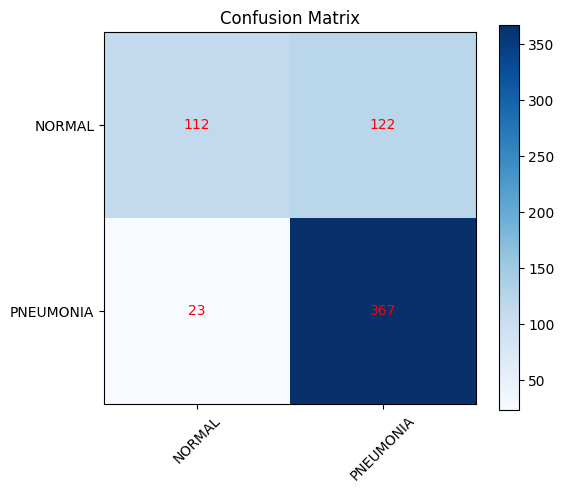

In [34]:
cm = confusion_matrix(y_test, test_preds)

plt.figure(figsize=(6,5))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.colorbar()
plt.xticks(np.arange(len(class_names)), class_names, rotation=45)
plt.yticks(np.arange(len(class_names)), class_names)

for i in range(len(class_names)):
    for j in range(len(class_names)):
        plt.text(j, i, cm[i, j], ha="center", va="center", color="red")

plt.show()


In [35]:
dump(rf, "random_forest_hog.pkl")
print("Model saved!")

Model saved!


In [36]:
def predict_image(image_path):
    features = extract_hog_features(image_path)
    pred = rf.predict([features])[0]
    prob = rf.predict_proba([features])[0]
    return class_names[pred], prob

label, prob = predict_image("IM-0122-0001.jpeg")
print("Predicted:", label)
print("Probabilities:", prob)


Predicted: PNEUMONIA
Probabilities: [0.29644723 0.70355277]
